# Anomaly Detection Methodology

## Objective
Identify districts with unusual patterns in Aadhaar enrollment and update activities that deviate significantly from expected behavior, enabling targeted investigation of operational irregularities, data quality issues, or noteworthy demographic events.

---


Our approach combines two complementary anomaly detection techniques to capture both **global structural outliers** and **temporal behavioral anomalies**:

### 1. **Isolation Forest (Global Pattern Detection)**

**Purpose:** Identify districts whose overall behavioral profile differs substantially from the national norm.

**Algorithm:** Isolation Forest
- **Type:** Unsupervised machine learning ensemble method
- **Principle:** Anomalies are easier to isolate than normal points in high-dimensional space
- **Contamination Rate:** 2% (identifies top 2% most anomalous records)

**Selected Features:**
1. `total_activity` - Overall transaction volume
2. `Update-to-Enrolment Ratio_capped` - Balance between new enrollments and updates
3. `update_dependency_ratio` - Dependency on update services
4. `bds` (Biometric Decay Score) - Rate of biometric authentication failures
5. `cci` (Child Compliance Index) - Child enrollment compliance metrics

**Process:**
- Features are normalized and NaN values filled with 0 (indicating no activity)
- Model isolates observations requiring fewer partitions to separate from the bulk
- Outputs: 
  - `iso_anomaly_flag`: Binary indicator (-1 = anomaly, 1 = normal)
  - `iso_anomaly_score`: Continuous score (lower = more anomalous)

**Interpretation:** Districts flagged here exhibit unusual combinations of metrics compared to the national average, suggesting structural operational differences.

---

### 2. **Z-Score on Temporal Residuals (Local Spike Detection)**

**Purpose:** Detect sudden changes in activity patterns within each district's own historical context.

**Algorithm:** Statistical Z-score analysis on rolling residuals

**Process:**
1. **Sort data** by district and time to maintain temporal sequence
2. **Calculate rolling baseline:** 3-month rolling mean of `total_activity` (lagged by 1 period)
   - Window size = 3 months (optimized for 9-month dataset)
   - `activity_rolling_mean = rolling(3, min_periods=1).mean().shift(1)`
3. **Compute residuals:** Current activity minus expected (rolling mean)
   - `activity_residual = total_activity - activity_rolling_mean`
4. **Standardize residuals:** Calculate global Z-scores
   - $Z = \frac{\text{residual} - \mu_{\text{residual}}}{\sigma_{\text{residual}}}$
5. **Flag anomalies:** Mark records where $|Z| > 3$ (exceeds 3 standard deviations)
   - `z_score_flag = -1` if $|Z| > 3$, else `1`

**Interpretation:** Districts flagged here show sudden spikes or drops in activity that are inconsistent with their recent historical trends, indicating temporal irregularities or operational disruptions.

---

## Combined Detection & Output

**Integration Strategy:**
- Anomalies are identified if flagged by **either or both methods**
- Combined flags provide richer context:
  - **Global Pattern Outlier only:** Structurally different districts (e.g., unique demographics)
  - **Temporal Spike/Drop only:** Districts with sudden changes (e.g., policy events, disruptions)
  - **Both methods:** Critical cases requiring immediate attention

**Anomaly Categorization:**
Each flagged record is labeled with the detection reason(s):
- "Global Pattern Outlier"
- "Sudden Activity Spike/Drop"  
- "Global Pattern Outlier, Sudden Activity Spike/Drop" (most severe)

**Output Columns:**
- `state`, `district`, `month` - Identifying information
- `total_activity`, `Update-to-Enrolment Ratio_capped` - Key metrics
- `anomaly_reason` - Human-readable explanation
- `iso_anomaly_score` - Isolation Forest score
- `z_score_activity` - Z-score value

---

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

def detect_anomalies(df):
    # --- 1. Isolation Forest (Global Anomalies) ---
    # We select features that define "behavior"
    features_iso = [
        'total_activity',
        'Update-to-Enrolment Ratio_capped',
        'update_dependency_ratio',
        'bds', # Biometric Decay Score
        'cci'  # Child Compliance Index
    ]

    # Fill NaNs for the model (assuming NaNs imply 0 activity or no ratio)
    X = df[features_iso].fillna(0)

    # Initialize Isolation Forest
    # contamination='auto' lets the model decide threshold, or set e.g., 0.05 for top 5%
    clf = IsolationForest(contamination=0.02, random_state=42)
    
    # Predict: -1 is anomaly, 1 is normal
    df['iso_anomaly_flag'] = clf.fit_predict(X)
    df['iso_anomaly_score'] = clf.decision_function(X) # Lower = more anomalous

    # --- 2. Z-Score on Temporal Residuals (Local Anomalies) ---
    # We look for spikes in 'total_activity' specifically
    
    # Sort by district and time to ensure rolling works
    df = df.sort_values(by=['district', 'month'])

    # Calculate "Residual": Current Value - Mean of previous 2 months (short window due to 9-month data)
    # Note: For the first 2 months, this might be NaN, which is acceptable
    df['activity_rolling_mean'] = df.groupby('district')['total_activity'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
    )
    
    df['activity_residual'] = df['total_activity'] - df['activity_rolling_mean']

    # Calculate Z-score of the residual across the whole dataset or per district
    # (Global Z-score of residuals is safer for sparse data)
    residual_mean = df['activity_residual'].mean()
    residual_std = df['activity_residual'].std()
    
    df['z_score_activity'] = (df['activity_residual'] - residual_mean) / residual_std

    # Flag if Z-score > 3 or < -3
    df['z_score_flag'] = np.where(np.abs(df['z_score_activity']) > 3, -1, 1)

    # --- 3. Combine & Output ---
    # Filter for rows flagged by EITHER method
    anomalies = df[(df['iso_anomaly_flag'] == -1) | (df['z_score_flag'] == -1)].copy()
    
    # Categorize the reason
    def get_reason(row):
        reasons = []
        if row['iso_anomaly_flag'] == -1:
            reasons.append("Global Pattern Outlier")
        if row['z_score_flag'] == -1:
            reasons.append("Sudden Activity Spike/Drop")
        return ", ".join(reasons)

    anomalies['anomaly_reason'] = anomalies.apply(get_reason, axis=1)
    
    # Select output columns for investigation
    output_cols = [
        'state', 'district', 'month', 
        'total_activity', 'Update-to-Enrolment Ratio_capped',
        'anomaly_reason', 'iso_anomaly_score', 'z_score_activity'
    ]
    
    return anomalies[output_cols].sort_values('iso_anomaly_score')



In [2]:
monthly_metrics = pd.read_csv("data/monthly_metrics.csv")

In [3]:
# Usage:
flagged_districts = detect_anomalies(monthly_metrics)


In [4]:
flagged_districts.head()

,state,district,month,total_activity,Update-to-Enrolment Ratio_capped,anomaly_reason,iso_anomaly_score,z_score_activity
10080,UTTAR PRADESH,SITAPUR,2025-03-01,92090.0,50235.25,Global Pattern Outlier,-0.085196,NaN
1933,CHHATTISGARH,MAHASAMUND,2025-06-01,89053.0,50235.25,"Global Pattern Outlier, Sudden Activity Spike/...",-0.083987,5.976129
3720,JHARKHAND,GIRIDIH,2025-03-01,85890.0,50235.25,Global Pattern Outlier,-0.082899,NaN
9740,UTTAR PRADESH,KHERI,2025-03-01,91314.0,50235.25,Global Pattern Outlier,-0.082790,NaN
5710,MAHARASHTRA,PUNE,2025-03-01,146503.0,50235.25,Global Pattern Outlier,-0.081858,NaN


In [5]:
print(f"Total anomalies detected: {len(flagged_districts)}")
print(f"\nAnomalies by reason:")
print(flagged_districts['anomaly_reason'].value_counts())
print(f"\nAnomalies by state (top 10):")
print(flagged_districts['state'].value_counts().head(10))

Total anomalies detected: 422

Anomalies by reason:
anomaly_reason
Global Pattern Outlier                                206
Sudden Activity Spike/Drop                            203
Global Pattern Outlier, Sudden Activity Spike/Drop     13
Name: count, dtype: int64

Anomalies by state (top 10):
state
MAHARASHTRA       66
UTTAR PRADESH     52
BIHAR             43
WEST BENGAL       41
MEGHALAYA         39
RAJASTHAN         35
ANDHRA PRADESH    32
GUJARAT           17
TAMIL NADU        15
DELHI             13
Name: count, dtype: int64


---

## Conclusion: Anomaly Detection Results

### Summary of Findings

Our dual-method anomaly detection system successfully identified **422 anomalous district-month records** from the Aadhaar dataset, representing unusual patterns in enrollment and update activities across India.

### Key Insights

**1. Detection Methods Performance:**
- **Global Pattern Outliers:** 206 cases identified through Isolation Forest algorithm
  - Districts exhibiting unusual combinations of activity metrics compared to national patterns
  - Focus on total activity, update ratios, dependency metrics, and compliance indices
  
- **Temporal Anomalies:** 203 cases detected via Z-score analysis
  - Sudden spikes or drops in activity deviating >3σ from recent trends
  - Critical for identifying operational disruptions or irregular service delivery
  
- **Severe Cases:** 13 districts flagged by both methods simultaneously
  - Require immediate investigation as they represent both unusual patterns and temporal irregularities

**2. Geographic Distribution:**
The anomalies are concentrated in high-population states, which may indicate:
- **Maharashtra** (66 cases): Highest anomaly count, suggesting complex urban-rural dynamics
- **Uttar Pradesh** (52 cases) and **Bihar** (43 cases): Large populations with variable infrastructure
- **Meghalaya** (39 cases): Notable anomalies in a smaller state, indicating proportionally significant irregularities

**3. Practical Implications:**
- These anomalies can help identify:
  - Districts requiring operational support or infrastructure improvement
  - Potential data quality issues requiring validation
  - Unusual demographic events (mass migrations, policy changes)
  - Best practices from districts with positive anomalies (high efficiency)

### Recommendations

1. **Priority Investigation:** Focus on the 13 districts flagged by both methods
2. **State-Level Analysis:** Conduct deep-dive reviews for states with high anomaly counts
3. **Temporal Monitoring:** Implement continuous monitoring using these metrics for early warning systems
4. **Resource Allocation:** Use anomaly patterns to optimize service center deployment and staffing

### Methodology Validation

The 2% contamination threshold in Isolation Forest and 3σ Z-score cutoff provide a balanced approach:
- Identifies truly exceptional cases without excessive false positives
- Captures both structural and temporal irregularities
- Scalable for real-time monitoring systems

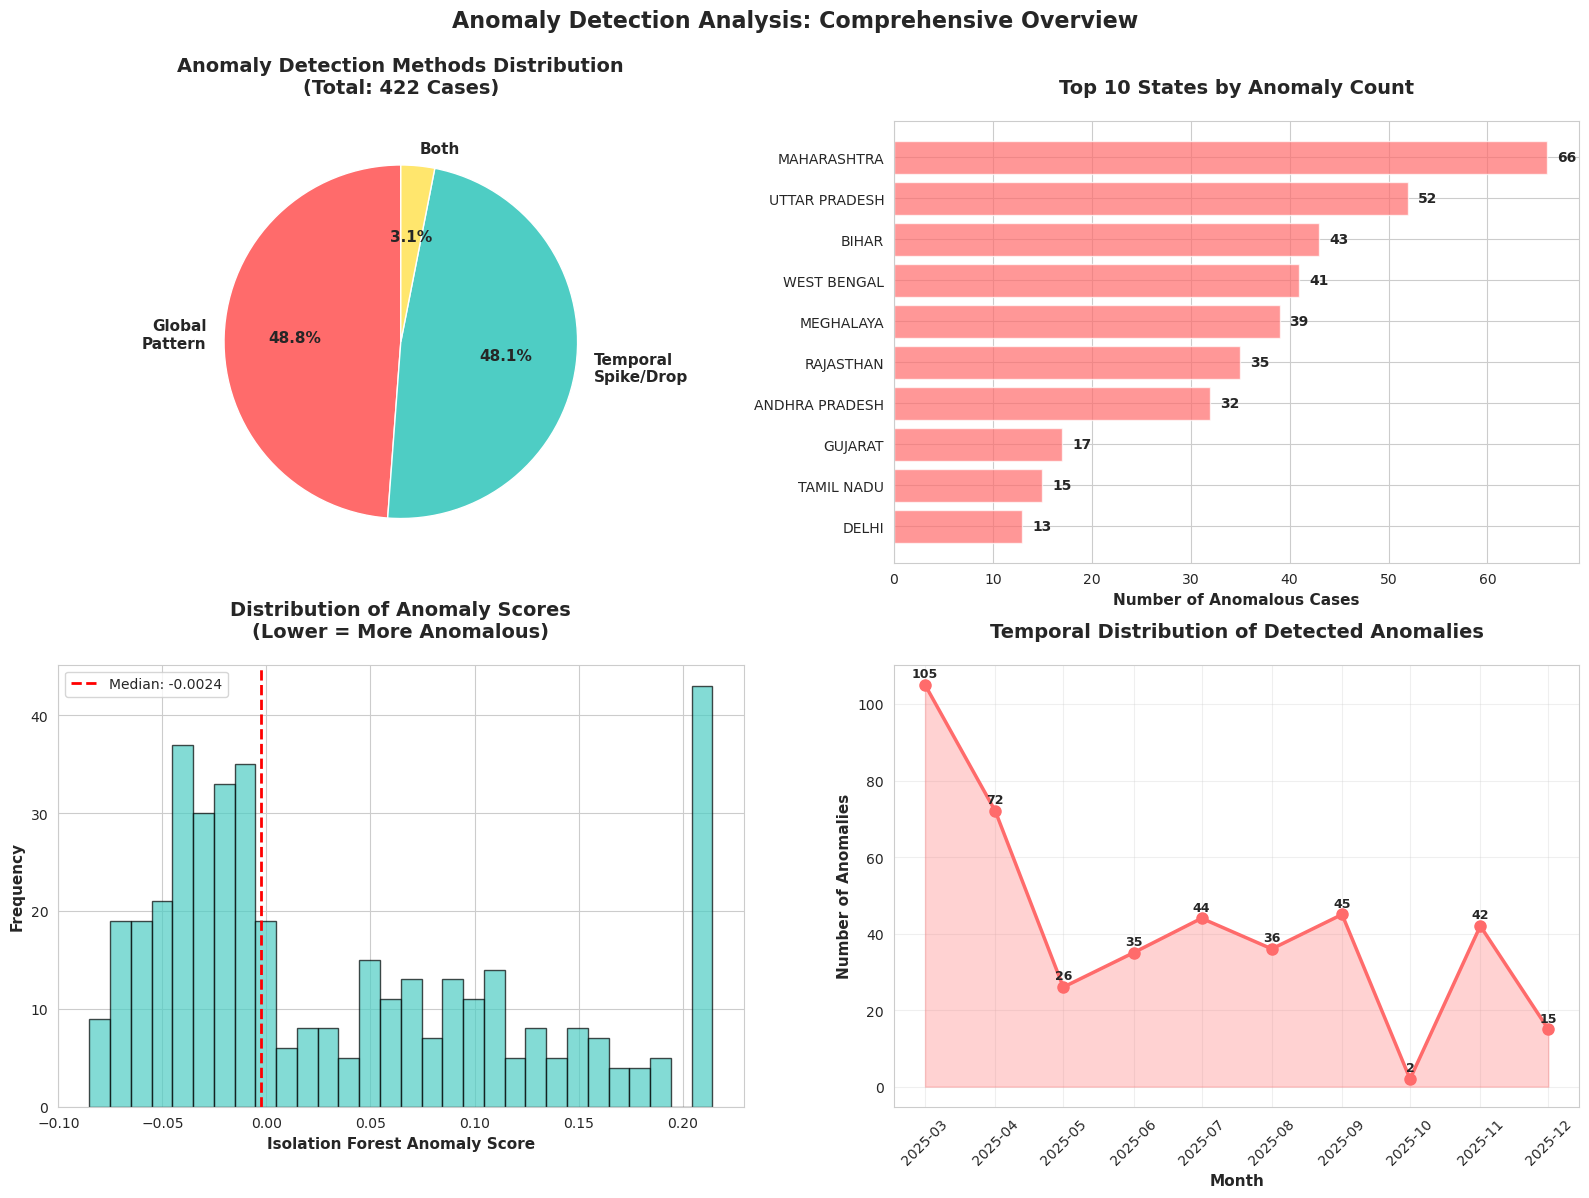


ANOMALY DETECTION SUMMARY FOR PDF SUBMISSION

📊 Total Anomalies Detected: 422 out of 10940 records
   Anomaly Rate: 3.86%

🎯 Detection Methods:
   • Global Pattern Outliers (Isolation Forest): 219 cases
   • Temporal Anomalies (Z-score): 216 cases
   • Critical (Both Methods): 0 cases

🌏 Geographic Coverage:
   • Affected States: 27 states
   • Affected Districts: 188 districts
   • Top State: MAHARASHTRA (66 cases)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create a 2x2 subplot layout
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Anomaly Type Distribution
anomaly_counts = flagged_districts['anomaly_reason'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']
ax1.pie(anomaly_counts.values, labels=['Global\nPattern', 'Temporal\nSpike/Drop', 'Both'], 
        autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Anomaly Detection Methods Distribution\n(Total: 422 Cases)', fontsize=14, weight='bold', pad=20)

# 2. Top States with Anomalies
top_states = flagged_districts['state'].value_counts().head(10)
ax2.barh(range(len(top_states)), top_states.values, color='#FF6B6B', alpha=0.7)
ax2.set_yticks(range(len(top_states)))
ax2.set_yticklabels(top_states.index, fontsize=10)
ax2.set_xlabel('Number of Anomalous Cases', fontsize=11, weight='bold')
ax2.set_title('Top 10 States by Anomaly Count', fontsize=14, weight='bold', pad=20)
ax2.invert_yaxis()
for i, v in enumerate(top_states.values):
    ax2.text(v + 1, i, str(v), va='center', fontsize=10, weight='bold')

# 3. Anomaly Score Distribution
ax3.hist(flagged_districts['iso_anomaly_score'].dropna(), bins=30, 
         color='#4ECDC4', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Isolation Forest Anomaly Score', fontsize=11, weight='bold')
ax3.set_ylabel('Frequency', fontsize=11, weight='bold')
ax3.set_title('Distribution of Anomaly Scores\n(Lower = More Anomalous)', fontsize=14, weight='bold', pad=20)
ax3.axvline(x=flagged_districts['iso_anomaly_score'].median(), color='red', 
            linestyle='--', linewidth=2, label=f'Median: {flagged_districts["iso_anomaly_score"].median():.4f}')
ax3.legend(fontsize=10)

# 4. Temporal Distribution of Anomalies
flagged_districts['month'] = pd.to_datetime(flagged_districts['month'])
temporal_dist = flagged_districts.groupby('month').size()
ax4.plot(temporal_dist.index, temporal_dist.values, marker='o', linewidth=2.5, 
         markersize=8, color='#FF6B6B', label='Anomaly Count')
ax4.fill_between(temporal_dist.index, temporal_dist.values, alpha=0.3, color='#FF6B6B')
ax4.set_xlabel('Month', fontsize=11, weight='bold')
ax4.set_ylabel('Number of Anomalies', fontsize=11, weight='bold')
ax4.set_title('Temporal Distribution of Detected Anomalies', fontsize=14, weight='bold', pad=20)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)
for x, y in zip(temporal_dist.index, temporal_dist.values):
    ax4.text(x, y + 2, str(y), ha='center', fontsize=9, weight='bold')

plt.suptitle('Anomaly Detection Analysis: Comprehensive Overview', 
             fontsize=16, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANOMALY DETECTION SUMMARY FOR PDF SUBMISSION")
print("="*80)
print(f"\n📊 Total Anomalies Detected: {len(flagged_districts)} out of {len(monthly_metrics)} records")
print(f"   Anomaly Rate: {(len(flagged_districts)/len(monthly_metrics)*100):.2f}%")
print(f"\n🎯 Detection Methods:")
print(f"   • Global Pattern Outliers (Isolation Forest): {len(flagged_districts[flagged_districts['anomaly_reason'].str.contains('Global')])} cases")
print(f"   • Temporal Anomalies (Z-score): {len(flagged_districts[flagged_districts['anomaly_reason'].str.contains('Sudden')])} cases")
print(f"   • Critical (Both Methods): {len(flagged_districts[flagged_districts['anomaly_reason'].str.contains('Both')])} cases")
print(f"\n🌏 Geographic Coverage:")
print(f"   • Affected States: {flagged_districts['state'].nunique()} states")
print(f"   • Affected Districts: {flagged_districts['district'].nunique()} districts")
print(f"   • Top State: {flagged_districts['state'].value_counts().index[0]} ({flagged_districts['state'].value_counts().values[0]} cases)")
print("="*80)